# Estimate the contribution of the integral constraint to the window matrix:

Following Chaussidon et al. 2024 (https://arxiv.org/abs/2411.17623). 

Note: For now the geometrical part of the window does not contain the wide-angle effects, so it also account for it !

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from clustering_statistics.tools import get_stats_fn

from tools import read_data, rebin_data

plt.style.use('ec_style.mplstyle')   

[Mac.dhcp.lbnl.us:09751] shmem: mmap: an error occurred while determining whether or not /var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T//ompi.Mac.501/jf.0/538968064/sm_segment.Mac.501.20200000.0 could be created.


In [2]:
def compute_integral_constraint_contribution(stats_dir, project, data_dir, tracer, region, zrange, style='RIC+AMR',
                                             ellsin=[0, 2], initial_params=None, ncall=5, hard_limits=False):
    from integral_constraints import WindowIC
    from clustering_statistics.tools import get_stats_fn
    import lsstypes 

    weight = 'default-fkp-oqe'
    print(f'Load mocks for covariance with : {weight=}')
    fns_cov = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                    weight=weight, imock=imock) for imock in range(1000)]
    for i, bad_mocks in enumerate([363, 565]):
        _ = fns_cov.pop(bad_mocks - i)  # don't forget pop remove the object from the list, so the next bad_mocks index is shifted by -1.
    pks_cov = [lsstypes.read(fn) for fn in fns_cov]

    weight = 'default-noimsys-fkp-oqe_reshuffle'
    print(f'Load mocks without IC with : {weight=}')
    fns_noic = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                    weight=weight, imock=imock) for imock in range(50)]
    pks_noic = [lsstypes.read(fn) for fn in fns_noic]

    if style == 'RIC+AMR':
        weight = 'default-fkp-oqe'
    if style == 'RIC':
        weight = 'default-noimsys-fkp-oqe'
    print(f'Load mocks with IC with : {weight=}')
    fns = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                    weight=weight, imock=imock) for imock in range(50)]
    pks = [lsstypes.read(fn) for fn in fns]

    print('Load Window Matrix:')
    _, wmatrix, _, _ = read_data(data_dir=data_dir, tracer=tracer, zrange=zrange, weight_type='default-fkp-oqe', region=region)

    # Estimate the IC contribution and build the window matrix with IC:
    IC = WindowIC(wmatrix, pks_noic, pks, pks_cov, ellsin=ellsin)

    _ = IC.fit(ncall=ncall, initial_params=initial_params, hard_limits=hard_limits)
    print('Best fit parameters: ', IC.bestfit_params)
    
    fn_wm_ic = get_stats_fn(stats_dir=data_dir, tracer=tracer, zrange=zrange, weight='default-fkp-oqe', region=region, kind='window_mesh2_spectrum', extra='DR1-' + style)
    print(fn_wm_ic)
    _ = IC.build_wmatrix_with_ic(save_fn=fn_wm_ic)

    IC.plot_validation()

LRG (0.4, 1.1) GCcomb
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0.0001, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:00<00:00,  7.39it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 354.6                      │             Nfcn = 1262              │
│ EDM = 2.6e-10 (Goal: 0.0002)     │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.006920714014845681, -6

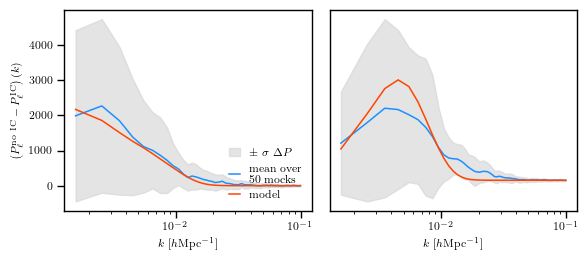

LRG (0.4, 1.1) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 1e-06, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:00<00:00,  9.17it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 236.7                      │             Nfcn = 1136              │
│ EDM = 1.72e-06 (Goal: 0.0002)    │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.007150609875394821, -2

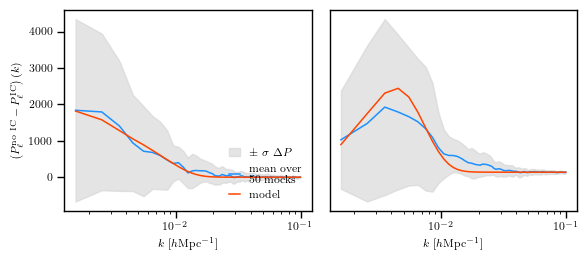

LRG (0.4, 1.1) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 1e-06, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:00<00:00,  5.52it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 389.5                      │             Nfcn = 1749              │
│ EDM = 1.34e-10 (Goal: 0.0002)    │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [412.33801794866014, -1.21

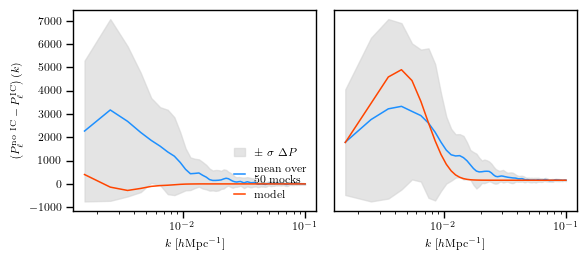

QSO (0.8, 3.5) GCcomb
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:04<00:00,  1.24it/s]


Valid minimum? False
Entering while loop because of INVALID minimum [1 / 3]
Entering while loop because of INVALID minimum [2 / 3]
Entering while loop because of INVALID minimum [3 / 3]
Valid minimum? False
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 813.8                      │             Nfcn = 10599             │
│ EDM = 1.35e-05 (Goal: 0.0002)    │            time = 1.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED         

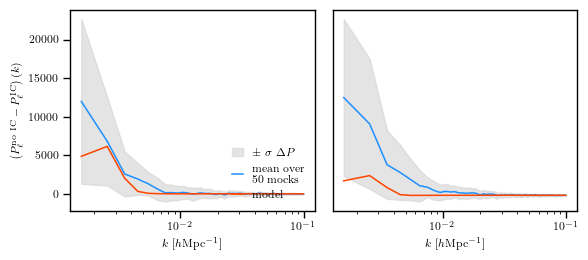

QSO (0.8, 3.5) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:01<00:00,  4.93it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 691.6                      │             Nfcn = 1768              │
│ EDM = 6.36e-10 (Goal: 0.0002)    │            time = 0.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.0001726302073883301, -0

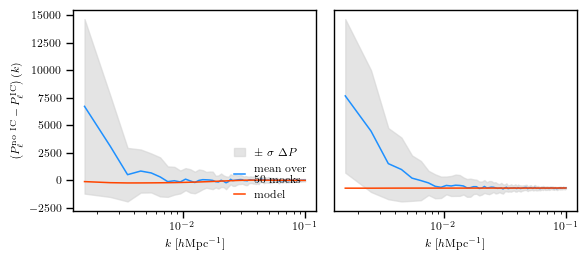

QSO (0.8, 3.5) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:03<00:00,  1.26it/s]


Valid minimum? False
Entering while loop because of INVALID minimum [1 / 3]
Entering while loop because of INVALID minimum [2 / 3]
Entering while loop because of INVALID minimum [3 / 3]
Valid minimum? False
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 832.3                      │             Nfcn = 9945              │
│ EDM = 2.44e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED         

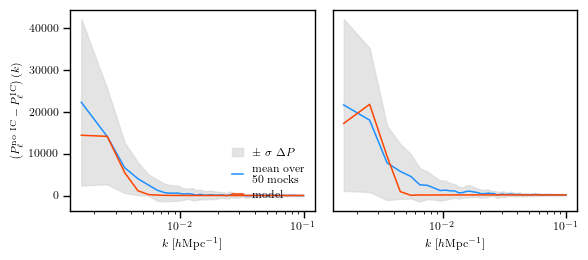

ELGnotqso (0.8, 1.6) GCcomb
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:00<00:00,  5.16it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3403                       │             Nfcn = 1422              │
│ EDM = 3.8e-09 (Goal: 0.0002)     │            time = 0.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-6.80158039979005e-05, 9.

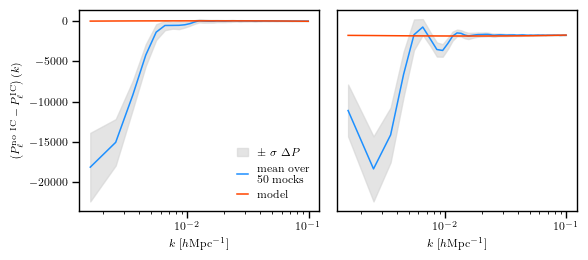

ELGnotqso (0.8, 1.6) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:00<00:00,  7.20it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1515                       │             Nfcn = 1284              │
│ EDM = 1.35e-10 (Goal: 0.0002)    │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [3.648556809654755, 7.0393

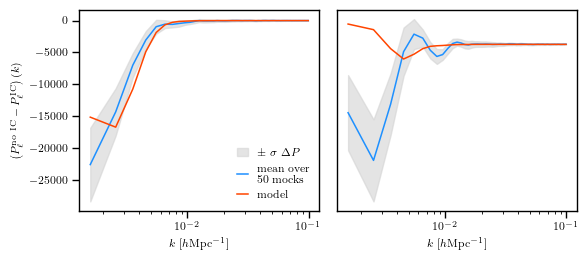

ELGnotqso (0.8, 1.6) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=5, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 5/5 [00:00<00:00,  9.87it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3723                       │              Nfcn = 958              │
│ EDM = 1.9e-10 (Goal: 0.0002)     │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.8890217941449512, -1.96

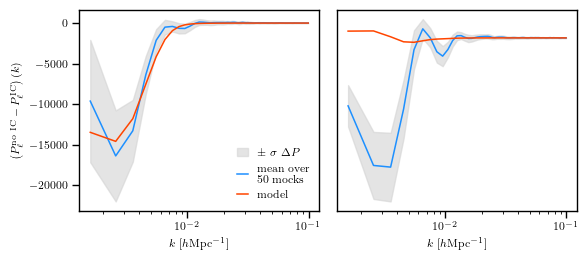

LRGxQSO (0.8, 1.1) GCcomb
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:03<00:00,  2.90it/s]


Valid minimum? False
Entering while loop because of INVALID minimum [1 / 3]
Entering while loop because of INVALID minimum [2 / 3]
Entering while loop because of INVALID minimum [3 / 3]
Valid minimum? False
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 431                        │             Nfcn = 7818              │
│ EDM = 6.2e-08 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED         

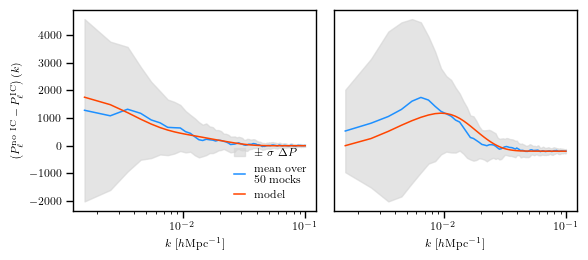

LRGxQSO (0.8, 1.1) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:00<00:00, 14.60it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 397.8                      │             Nfcn = 1603              │
│ EDM = 7.63e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.0006144041612861084, -

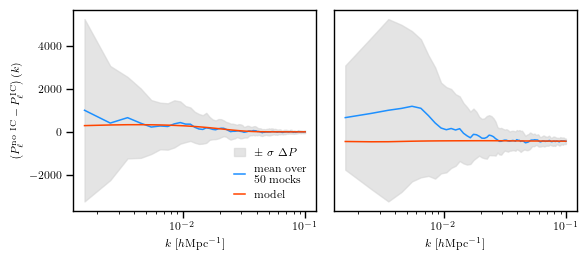

LRGxQSO (0.8, 1.1) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[0.0001, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:02<00:00,  3.37it/s]


Valid minimum? False
Entering while loop because of INVALID minimum [1 / 3]
Entering while loop because of INVALID minimum [2 / 3]
Entering while loop because of INVALID minimum [3 / 3]
Valid minimum? False
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 472.4                      │             Nfcn = 6652              │
│ EDM = 2.84e-10 (Goal: 0.0002)    │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED         

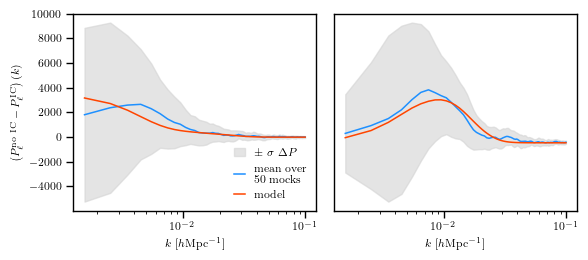

LRGxELGnotqso (0.8, 1.1) GCcomb
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:01<00:00,  7.39it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 396.1                      │             Nfcn = 2920              │
│ EDM = 8.98e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.0023481150598290146, -

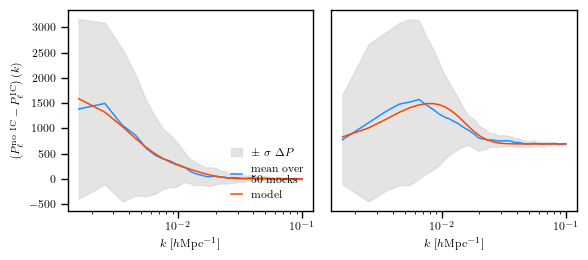

LRGxELGnotqso (0.8, 1.1) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:03<00:00,  2.83it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 335.1                      │             Nfcn = 5939              │
│ EDM = 1.81e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.0033995316521582275, 0

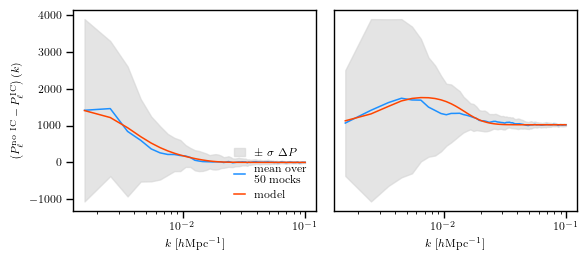

LRGxELGnotqso (0.8, 1.1) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:02<00:00,  4.63it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 573.5                      │             Nfcn = 3360              │
│ EDM = 2.09e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.9999999999409994, -8.5

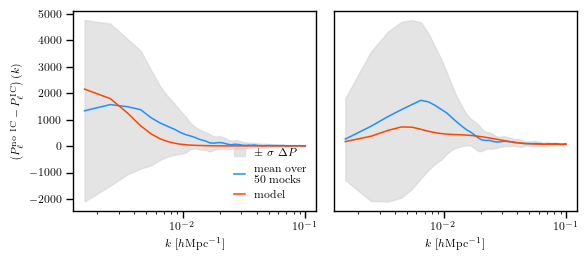

ELGnotqsoxQSO (0.8, 1.6) GCcomb
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:01<00:00,  7.71it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 735.2                      │             Nfcn = 2614              │
│ EDM = 2.39e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.9999999955854337, -0.00

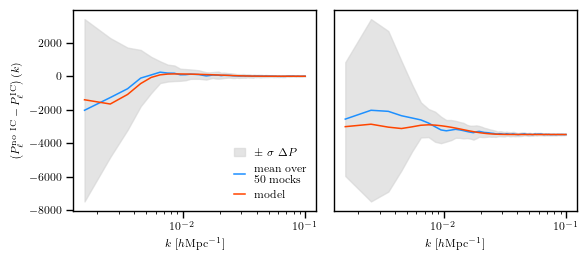

ELGnotqsoxQSO (0.8, 1.6) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:01<00:00,  5.59it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 638.9                      │             Nfcn = 2997              │
│ EDM = 9.02e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.9942562366104037, 5.727

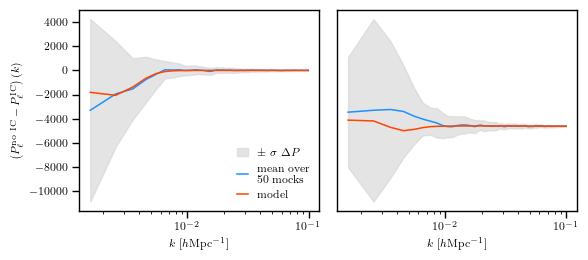

ELGnotqsoxQSO (0.8, 1.6) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-noimsys-fkp-oqe'
Load Window Matrix:
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:01<00:00,  9.22it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 917.7                      │             Nfcn = 1816              │
│ EDM = 7.13e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [-0.0008728011335431551, -

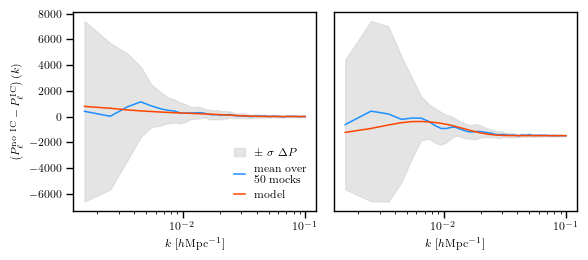

In [4]:
# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

stats_dir = root + 'dr2/summary_statistics/local_png/base'
project = 'holi-v3-altmtl/'

data_dir = root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/'

tracers = ['LRG', 'QSO', 'ELGnotqso', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']
zranges = {'LRG': [(0.4, 1.1)], 'QSO': [(0.8, 3.5)], 'ELGnotqso': [(0.8, 1.6)], 
           'LRGxQSO': [(0.8, 1.1)], 'LRGxELGnotqso': [(0.8, 1.1)], 'ELGnotqsoxQSO': [(0.8, 1.6)]}

regions = {tracer: ['GCcomb', 'NGC', 'SGC'] for tracer in tracers} 

to_compute = ['RIC+AMR', 'RIC']

for tracer in tracers:
    for zrange in zranges[tracer]:
        for region in regions[tracer]:
            print(tracer, zrange, region)

            if tracer in ['LRG', 'QSO', 'ELGnotqso']:
                if tracer == 'LRG':
                    if region == 'GCcomb':
                        initial_params = [1e-4,0,1e-4,0]+[1,1,1,1]
                    else:
                        initial_params = [1e-4,0,1e-6,0]+[1,1,1,1]
                else: 
                    initial_params = [1e-4,0,0,0]+[1,1,1,1]
                ncall = 5 
                hard_limits = False
                
            else:
                if tracer == 'LRGxQSO':
                    initial_params = [1e-4,0,0,0]+[1,1,1,1]
                else:
                    initial_params = [1e-5,0,0,0]+[1,1,1,1]
                ncall = 10
                hard_limits = True

            for style in to_compute:            
                compute_integral_constraint_contribution(stats_dir, project, data_dir, tracer, region, zrange, style=style,
                                                ellsin=[0, 2], initial_params=initial_params, ncall=ncall, hard_limits=hard_limits)


/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v3-altmtl/mock0/mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-noimsys-fkp-oqe_reshuffle.h5
/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v3-altmtl/mock0/mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-noimsys-fkp-oqe.h5
/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v3-altmtl/mock0/mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-fkp-oqe.h5
/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v3-altmtl/mock0/mesh2_spectrum_poles_LRG_z0.4-1.1_NGC_weight-default-noimsys-fkp-oqe_reshuffle.h5
/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v3-altmtl/mock0/mesh2_spectrum_poles_LRG_z0.4-1.1_NGC_weight-default-noimsys-fkp-oqe.h5
/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/holi-v3-altmtl/mock0/mesh2_spectrum_poles_LRG_

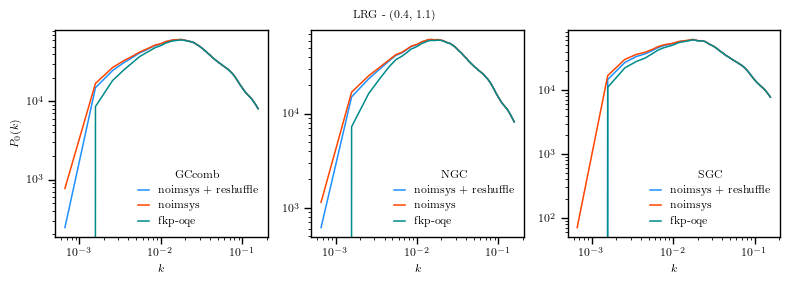

In [ ]:
from clustering_statistics.tools import get_stats_fn
import lsstypes 

#tracer = 'QSO'
#zrange = (0.8, 3.5)

tracer = 'LRG'
zrange = (0.4, 1.1)

plt.figure(figsize=(8, 3))

for i, region in enumerate(['GCcomb', 'NGC', 'SGC']):
    plt.subplot(1, 3, i+1)

    for weight in ['default-noimsys-fkp-oqe_reshuffle', 'default-noimsys-fkp-oqe', 'default-fkp-oqe']:

        fns = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                        weight=weight, imock=imock) for imock in range(50)]
        print(fns[0])
        pks = [lsstypes.read(fn) for fn in fns]
        pk = lsstypes.mean(pks)
        label = weight.replace('default-', '').replace('-fkp-oqe', '').replace('_reshuffle', ' + reshuffle')
        plt.loglog(pk.get(0).k, pk.get(0).value(), label=label)

    plt.legend(title=region)
    plt.xlabel('$k$')
    if i == 0: plt.ylabel('$P_0(k)$')

plt.suptitle(f'{tracer} - {zrange}', y=0.93, fontsize=8)
plt.tight_layout()
plt.savefig(f'fig/integral_constraints_contribution_{tracer}.png', dpi=400)
plt.show()